# CIS I — Assignment 1: Pivot Calibration

This notebook walks through the pivot-calibration scenario from the
assignment (Figure 1): a pointer and a calibration object, each
carrying a marker body, observed by an optical tracker. Your job is to
**design** the marker-sphere layouts and workspace placements, then
**calibrate** the pointer's tip position `p_tip` to within about 2mm.

Everything runs against `src.simulation`, a self-contained simulator that plays the role of the physical tracker +
hand-guided robot + calibration sensor described in the handout. It injects measurement noise — your code never sees ground truth
except where explicitly noted for **validation/reporting** in Step 8 (real
hardware wouldn't give you that; the point there is to report your achieved
accuracy, not to use the ground truth in your calibration math itself).



In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
from src import simulation
from src import vct3, Rot, Frame

np.set_printoptions(precision=3, suppress=True)
%pip install nbclient nbformat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#constants
N_TEST_POSES = 100
TIP_ERROR_SPEC_MM = 2

In [3]:
from src.simulation import constants
print({k: getattr(constants, k) for k in dir(constants) if k.isupper()})

{'BODY_PLACEMENT_ANGLE_STD': 0.03577817531305904, 'BODY_PLACEMENT_POS_STD': 8.94454382826476, 'CAL_SENSOR_NOISE_STD': 0.002, 'CAL_SENSOR_RANGE_MM': 5.0, 'HAND_GUIDE_ANGLE_STD': 0.05, 'HAND_GUIDE_POS_STD': 1.7889087656529516, 'MARKER_MANUFACTURING_STD': 0.7155635062611807, 'SAMPLE_DELTA_T_SEC': 0.03, 'SENSOR_NOISE_STD': 0.02, 'TEST_POSE_ANGLE_STD': 0.02, 'TEST_POSE_POS_STD': 0.7155635062611807, 'TRACKER_JIGGLE_ANGLE_STD': 0.01, 'TRACKER_JIGGLE_POS_STD': 5.0, '_CHI3_95': 2.795}


## Step 1: Design the pointer's marker body

Choose approximate local marker-sphere positions `a_ptr,k` (a `List[vct3]`,
relative to the pointer's own coordinate frame) and the pointer tip's
approximate local position `p_tip_approx`. These are your
*nominal design values* — the simulator will independently perturb the
*actual* manufactured positions by a small, noise amount (bounded at
2mm).


In [ ]:
ptr_local_positions = [
    vct3(0, 0, 0),
    vct3(250, 0, 0),
    vct3(0, 190, 0),
    vct3(60, 120, 160)
]
ptr_tip_approx = vct3(0, 0, -50) # 50mm below the marker cluster


## Step 1.1: Design the calibration object's marker body

Same idea, for the calibration object's local marker positions `a_cal,k`.


In [ ]:
cal_local_positions = [
    vct3(0, 0, 0),
    vct3(300, 0, 0),
    vct3(0, 270, 0),
    vct3(90, 120, 180)
]


## Step 2: Approximate workspace poses

Specify approximate poses (as `Frame` class from src) for the tracking camera
(`F_tracker`) and the calibration object (`F_cal`), relative to the
workspace. The tracker's usable volume is the tetrahedral region in the
handout's Figure 2 (roughly 100-200cm in front of the tracker, widening
from ~120cm to ~200cm across) — place the calibration object, and later
the pointer, so they're inside that volume.


In [ ]:
F_tracker_approx = Frame(Rot(), vct3(300, 300, -1500))  # Frame, tracker pose relative to the workspace
F_cal_approx = Frame(Rot(), vct3(300, 300, 300))  # Frame, calibration object pose relative to the workspace


## Step 3: Build the simulation

Fully provided — this just wires up your Step 1/2 design choices through
`simulation`'s `DefineMarkerBody` / `PlaceMarkerBody` / `CreateTracker`
equivalents. `ptr_placed`/`cal_placed` are `PlacedBody` handles: each pairs
a `MarkerBody` with its hidden actual placement, and gets passed to
`simulation.sample_marker_bodies(...)` whenever you want a reading.


In [7]:
ptr_mb = simulation.define_marker_body("ptr_mb", ptr_local_positions)
cal_mb = simulation.define_marker_body("cal_mb", cal_local_positions)

cal_placed = simulation.place_marker_body(cal_mb, F_cal_approx)
# The pointer's own body doesn't have a meaningful "workspace placement" yet
# It moves every time it's hand-guided (Step 4-6). 
# precision="precise" matches a robot-controlled pose rather than a coarsely, manually placed
# static object (see place_marker_body's docstring).
ptr_placed = simulation.place_marker_body(ptr_mb, Frame.eye(), precision="precise")

ptr = simulation.define_pointer("ptr1", ptr_tip_approx, ptr_mb)
trk = simulation.create_tracker("trk1", F_tracker_approx)

print("simulation built:", ptr_mb.name, cal_mb.name, ptr.name, trk.name)


simulation built: ptr_mb cal_mb ptr1 trk1


## Step 3.1: Refine `a_ptr,k` / `a_cal,k`

> "Observations of marker positions can be used to determine accurate
> estimates of relative positions a_ptr,k of markers on pointer and
> calibration objects... **Hint**: You probably want to take multiple
> readings in order to reduce the uncertainty associated with the a_k
> values."


In [ ]:
def refine_marker_body(trk, placed, n_readings=200, passes=10):
    """
    input:
        trk - Tracker to read with
        placed - PlacedBody whose body's nominal marker positions should be
            refined in place (via body.set_marker_positions(...))
        n_readings - int, readings to average per pass
        passes - int, how many times to repeat
    output: None (mutates placed.body's nominal_marker_positions in place)
    """
    body = placed.body
    for i in range(passes):
        readings = []
        for j in range(n_readings):
            obs = simulation.sample_marker_bodies(trk, [placed])[body.name]         # one pose for the body, and position of the 4 markers in the tracker frame
            F_inv = obs.frame.inv()             # converts points from the tracker frame to the body frame

            this_reading = []
            for m in obs.markers:
                b = m.p             # b = the marker position in the tracker frame
                a = F_inv * b       # a = the same marker positions in the body frame
                this_reading.append(np.array(a.vec).reshape(3))
            readings.append(this_reading)
        
        averages = np.mean(readings, axis = 0)      # average each marker's position across all readings
        body.set_marker_positions([vct3(*row) for row in averages])
        print(f"{body.name} pass {i + 1} done")

refine_marker_body(trk, ptr_placed)         # refines positions of the pointer's markers in the pointer's local frame
refine_marker_body(trk, cal_placed)         # refines positions of the calibration object's markers in the calibration object's local frame


ptr_mb pass 1 done
ptr_mb pass 2 done
ptr_mb pass 3 done
ptr_mb pass 4 done
ptr_mb pass 5 done
ptr_mb pass 6 done
ptr_mb pass 7 done
ptr_mb pass 8 done
ptr_mb pass 9 done
ptr_mb pass 10 done
cal_mb pass 1 done
cal_mb pass 2 done
cal_mb pass 3 done
cal_mb pass 4 done
cal_mb pass 5 done
cal_mb pass 6 done
cal_mb pass 7 done
cal_mb pass 8 done
cal_mb pass 9 done
cal_mb pass 10 done


## Steps 4-6: Collect pivot-calibration observations

For each observation `j`: hand-guide the pointer near the calibration
object at some desired orientation `R_desired,j`, take one simultaneous
tracker reading of *both* bodies, and read the calibration sensor. Loop
skeleton is provided; you choose how many observations to take and how to
vary `R_desired,j`


In [ ]:
N_OBSERVATIONS = 50     # number of pivot calibration observatoins to collect

F_ptr_list = []         # pointer pose relative to the tracker
F_cal_list = []         # calibration object pose relative to the tracker
sensed_tip_list = []    # calibration sensor's tip reading
for j in range(N_OBSERVATIONS):
    R_desired = Rot.rand_xyz(np.pi/4, np.pi/4, np.pi)  # vary the desired pointer orientation across observations
    hg = simulation.hand_guide_pointer(ptr, ptr_placed, cal_placed, R_desired)  # hand guidede the pointer to R_desired near the calibration object
    obs = simulation.sample_marker_bodies(trk, [ptr_placed, cal_placed])        # one simulation tracker reading of both bodies
    sensed = simulation.sense_tip(ptr, hg)      # calibration sensor's reading of the tip position

    F_ptr_list.append(obs["ptr_mb"].frame)
    F_cal_list.append(obs["cal_mb"].frame)
    sensed_tip_list.append(sensed)

print(f"collected {len(F_ptr_list)} observations")


collected 50 observations


`sensed_tip_list` holds each observation's high-accuracy calibration-sensor
reading (or `None` if that observation ended up outside the sensor's 5mm
range) — useful as an independent sanity check on your calibration later,
since it measures the tip position a completely different way (directly,
rather than through the pointer's marker geometry).


## Step 7: Compute a calibrated value for `p_tip`

This is the assignment's core deliverable — implement it yourself and specify the details of implementation in the report.

**Corner case to consider**: What are the corner cases you want to analyse here?

**Minimum data**: how many observations, and what about their rotations,
are needed for the stacked system to actually be solvable? How do you define whether a system is solvable here? Include that in your report


In [ ]:
def compute_pivot_calibration(F_ptr_list, F_cal_list, sensed_tip_list):
    """
    input:
        F_ptr_list - List[Frame], the pointer marker body's pose relative to
            the tracker for each observation j (Fptr,j)
        F_cal_list - List[Frame], the calibration object's pose relative to
            the tracker for each observation j (Fcal,j), same order/length
    output:
        p_tip - vct3, the calibrated tip position in the pointer's local frame
        cov_estimate - np.ndarray (3x3), an estimated covariance for p_tip
            (e.g. from the least-squares fit's residuals)
    """
    A_blocks = []
    B_blocks = []

    for i in range(len(F_ptr_list)):
        if sensed_tip_list[i] is None:
            continue  # skip this observation if the tip was not sensed

        F_ptr = F_ptr_list[i]
        F_cal = F_cal_list[i]
        p_sensed = sensed_tip_list[i]
        F_j = F_cal.inv() * F_ptr   # pointer pose in the calibration object's frame
        R_j = F_j.R.matrix          # 3x3 rotation for the observation
        p_j = F_j.p.vec.ravel()     # 3x1 translation for the observation
        s_j = p_sensed.vec.ravel()  #sensed tip position, same frame as p_j

        A_blocks.append(R_j)        # 3x3 block for the observation
        B_blocks.append(s_j - p_j)  # 3x1 block for the observation

    A = np.vstack(A_blocks)         # Stacked system matrix of 3M x 3; where M is the number of valid observations
    B = np.concatenate(B_blocks)    # stacked right hand side of 3M x 1

    # least-squares solution to the linear system A * p_tip = B
    p_tip = np.linalg.inv(A.T @ A) @ A.T @ B 

    # residuals and covariance estimation
    residual = A @ p_tip - B
    num_unknowns = 3
    residual_variance = (residual @ residual) / (len(B) - num_unknowns)
    cov_estimate = residual_variance * np.linalg.inv(A.T @ A)

    return vct3(*p_tip), cov_estimate

p_tip_est, p_tip_cov = compute_pivot_calibration(F_ptr_list, F_cal_list, sensed_tip_list)



In [11]:
print("calibrated p_tip:", p_tip_est)
print("estimated covariance (mm^2):\n", p_tip_cov)
print("estimated std-dev per axis (mm):", np.sqrt(np.diag(p_tip_cov)))


calibrated p_tip: vct3(x=-1.05, y=-1.00, z=-51.57)
Internal Vector:
[[ -1.047]
 [ -0.997]
 [-51.573]]
estimated covariance (mm^2):
 [[ 0.001  0.    -0.   ]
 [ 0.     0.001 -0.   ]
 [-0.    -0.     0.001]]
estimated std-dev per axis (mm): [0.03 0.03 0.03]


## Step 8: Validate against test poses

> "**Hint**: You may want to consider placing additional marker bodies
> close to (but not inside) the cube defined by the test volume. However,
> this will also depend on your design for and placement of the
> calibration object."

The nominal test-pose grid is `theta_x, theta_y, theta_z` each in
`{0, +-pi/6, +-pi/3, +-pi/2}` and `p_x, p_y, p_z` each in
`{300, 300+-100, 300+-200}` mm. For each test pose, the assignment requires a
**single observation only** (no averaging).

Think about why the hint suggests an *additional*, nearby reference body?

In [ ]:
near_local_positions = [
    vct3(-150, -150, 0),
    vct3(150, -150, 0),
    vct3(0, 150, 0),
    vct3(0, 0, 95)
]
F_near_approx = Frame(Rot(), vct3(300, 400, 525))

near_mb = simulation.define_marker_body("near_mb", near_local_positions)
near_placed = simulation.place_marker_body(near_mb, F_near_approx)
refine_marker_body(trk, near_placed)


near_mb pass 1 done
near_mb pass 2 done
near_mb pass 3 done
near_mb pass 4 done
near_mb pass 5 done
near_mb pass 6 done
near_mb pass 7 done
near_mb pass 8 done
near_mb pass 9 done
near_mb pass 10 done


Refine this new body's geometry the same way you refined the pointer's and
calibration object's (Step 3b) before using it.


Now the single-observation test loop. For each nominal test pose `F_t`:
place the pointer there (small, robot-precision placement error, same as
the real system), take one simultaneous reading of the pointer and your
Step-8 reference body, and predict the tip's position (relative to that
reference body) using your calibrated `p_tip`.

**Ground truth for reporting only**: `PlacedBody.actual_placement` and
`MarkerBody.actual_marker_positions` hold the hidden values the simulator
sampled — you have access to them here only because this notebook doesn't
gate them behind a separate eval mode (per the handout: "During debugging
you will have access to all of the ... values. These will not be available
during evaluation."). Use them *only* to compute and report your achieved
error in this section — using them anywhere in your actual calibration math
(Steps 3b/7) kills the point of the assignment.


In [ ]:
thetas = [0, np.pi / 6, -np.pi / 6, np.pi / 3, -np.pi / 3, np.pi / 2, -np.pi / 2]
#offsets = [0, 100, -100, 200, -200]

#thetas = [0, np.pi / 6, -np.pi / 6, np.pi/3, -np.pi/3]
offsets = [0, 100, -100, 200, -200]
# the full grid above is large (7^3 * 5^3 = 42,875 combinations) --
# choose a representative subset of (position, orientation) test poses
# rather than every combination.

test_poses = [
    # build a list of Frame(Rot.xyz(rx, ry, rz), vct3(300+tx, 300+ty, 300+tz))
    # from thetas/offsets above
    # Frame(Rot.xyz(0, 0, 0), vct3(300, 300, 300)),
    # Frame(Rot.xyz(0, , 0), vct3(300, 300, 300)),
]

rng = np.random.default_rng(0)

chosen = set()
while len(test_poses) < N_TEST_POSES:
    pick = (rng.choice(thetas), rng.choice(thetas), rng.choice(thetas),
            rng.choice(offsets), rng.choice(offsets), rng.choice(offsets))
    if pick in chosen:
        continue 
    chosen.add(pick)
    rx, ry, rz, tx, ty, tz = pick
    test_poses.append(Frame(Rot.xyz(rx, ry, rz), vct3(300 + tx, 300 + ty, 300 + tz)))

tip = ptr.get_actual_tip_position()
true_tip_local = vct3(tip.x, tip.y, tip.z)

test_results = []  # list of (F_t_nominal, error_mm)

predicted_positions = []
true_positions = []

#------------ DIAGNOSTIC DEF ------------------
rotation_errors = []
translation_errors = []

# --------------- END DIAGNOSTIC DEF ----------------

for F_t_nominal in test_poses:
    # place the pointer at the test pose
    test_placed = simulation.place_marker_body(ptr_mb, F_t_nominal, precision="precise")

    # single simultaneous tracker teading of the pointer and the rederence body
    obs = simulation.sample_marker_bodies(trk, [test_placed, near_placed])
    F_ptr = obs["ptr_mb"].frame
    F_near = obs["near_mb"].frame
    
    # predict the tip position relative to near_placed using calibrated p_tip
    tip_predicted = F_near.inv() * (F_ptr * p_tip_est)
    #tip_predicted = F_near.inv() * (F_ptr * true_tip_local) # DIAGNOSTIC WITHOUT ERROR

    # compute the TRUE tip position relative to near_placed using
    F_real_true = near_placed.actual_placement.inv() * test_placed.actual_placement
    tip_true = F_real_true * true_tip_local
    
    #------------------------- DIAGNOSTIC -----------------------------------
    # Observed pointer pose relative to the reference
    F_observed = F_near.inv() * F_ptr

    # Actual pointer pose relative to the reference
    F_actual = (
        near_placed.actual_placement.inv()
        * test_placed.actual_placement
    )

    # Use observed rotation with actual translation
    tip_rotation_only = (
        F_observed.R * true_tip_local
        + F_actual.p
    )

    # Use actual rotation with observed translation
    tip_translation_only = (
        F_actual.R * true_tip_local
        + F_observed.p
    )

    rotation_errors.append(np.linalg.norm(tip_rotation_only.vec.ravel() - tip_true.vec.ravel()))

    translation_errors.append(np.linalg.norm(
        tip_translation_only.vec.ravel() - tip_true.vec.ravel()
    ))

# ----------------------- END DIAGNOSTIC -----------------------------------
    
    
    
    predicted_positions.append(
    tip_predicted.vec.ravel()
    )

    true_positions.append(
        tip_true.vec.ravel()
    )

    # record the error and append (F_t_nominal, error) to test_results
    error = np.linalg.norm(tip_predicted.vec.ravel() - tip_true.vec.ravel())
    test_results.append((F_t_nominal, error))

predicted_positions = np.array(predicted_positions)
true_positions = np.array(true_positions)

errors = []                                        
for i in range(len(test_results)):
    errors.append(test_results[i][1])
errors = np.array(errors)

print("test poses:  ", len(errors))
print("mean error (mm):  ", round(np.mean(errors)))
print("max error(mm):  ", round(np.max(errors)))

test poses:   100
mean error (mm):   1
max error(mm):   2


In [14]:
z_levels = [100, 200, 300, 400, 500]

print("z (mm) | poses | mean error (mm) | max error (mm)")
for z in z_levels:
    errors_at_z = []
    for i in range(len(test_results)):
        F_t_nominal = test_results[i][0]
        error = test_results[i][1]
        if F_t_nominal.p.vec.ravel()[2] == z:
            errors_at_z.append(error)

    if len(errors_at_z) == 0:
        print(z, "| 0 poses")
        continue
    errors_at_z = np.array(errors_at_z)
    print(z, "|", len(errors_at_z), "|", round(np.mean(errors_at_z), 3), "|", round(np.max(errors_at_z), 3))

z (mm) | poses | mean error (mm) | max error (mm)
100 | 23 | 1.439 | 1.989
200 | 12 | 1.211 | 1.704
300 | 27 | 0.933 | 1.555
400 | 14 | 0.82 | 1.563
500 | 24 | 0.842 | 1.717


## Achieved performance
Summarize the tip-position error across the test-pose grid against the
handout's 2mm spec.


In [ ]:
# summarize test_results -- e.g. mean/max error, and how many poses
# meet the assignment's ||delta p_t|| <= 2mm spec.

def summarize_tip_errors(error_norms, spec_mm=TIP_ERROR_SPEC_MM):
    error_norms = np.asarray(error_norms, dtype=float)
    return{
        'mean_mm': error_norms.mean(),
        'rms_mm': np.sqrt(np.mean(error_norms**2)),
        'max_mm': error_norms.max(),
        'std_mm': error_norms.std(),
        'worst_pose_index': int(error_norms.argmax()),
        'num_passing': int(np.sum(error_norms <= spec_mm)),
        'num_poses': len(error_norms),
    }


error_norms = [r[1] for r in test_results]
summary = summarize_tip_errors(error_norms)

print(f"Poses meeting {TIP_ERROR_SPEC_MM} mm spec: "
      f"{summary['num_passing']} /{summary['num_poses']}")
print(f"Mean error: {summary['mean_mm']: .3f} mm")
print(f"RMS error: {summary['rms_mm']: .3f} mm")
print(f"Max error: {summary['max_mm']: .3f} mm (pose {summary['worst_pose_index']})")
print(f"Std dev {summary['std_mm']: .3f} mm")

Poses meeting 2 mm spec: 100 /100
Mean error:  1.045 mm
RMS error:  1.122 mm
Max error:  1.989 mm (pose 23)
Std dev  0.409 mm


In [16]:
from scipy import stats
import numpy as np

# One-sided one-sample t-test against the 2 mm error specification
alpha = 0.05
spec_mm = TIP_ERROR_SPEC_MM

errors = np.asarray(errors, dtype=float)

n = len(errors)
mean_error = np.mean(errors)
std_error = np.std(errors, ddof=1)

# t statistic
t_stat = (
    mean_error - spec_mm
) / (
    std_error / np.sqrt(n)
)

# One-sided p-value for:
# H0: mean error >= 2 mm
# H1: mean error < 2 mm
p_value = stats.t.cdf(
    t_stat,
    df=n - 1
)

# 95% one-sided upper confidence bound for mean error
t_crit = stats.t.ppf(
    0.95,
    df=n - 1
)

upper_95 = (
    mean_error
    + t_crit * std_error / np.sqrt(n)
)

print(f"Number of poses: {n}")
print(f"Mean error: {mean_error:.3f} mm")
print(f"Standard deviation: {std_error:.3f} mm")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")
print(f"95% upper confidence bound: {upper_95:.3f} mm")

if p_value < alpha:
    print(
        "Reject H0: the mean localization error is "
        "significantly below 2 mm at the 95% confidence level."
    )
else:
    print(
        "Fail to reject H0: there is not sufficient evidence "
        "that the mean localization error is below 2 mm."
    )

Number of poses: 100
Mean error: 1.045 mm
Standard deviation: 0.411 mm
t-statistic: -23.245
p-value: 0.000000
95% upper confidence bound: 1.113 mm
Reject H0: the mean localization error is significantly below 2 mm at the 95% confidence level.


In [17]:
from scipy.stats import linregress
import numpy as np

# Extract z-position from each test pose
z_values = np.array([
    F.p.vec.ravel()[2]
    for F, error in test_results
])

# Extract corresponding localization errors
errors = np.array([
    error
    for F, error in test_results
])

slope, intercept, r_value, p_value, std_err = linregress(
    z_values,
    errors
)

print(f"Slope:   {slope:.5f} mm error / mm z")
print(f"R^2:     {r_value**2:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("There is a statistically significant relationship between z-position and localization error.")
else:
    print("There is not a statistically significant relationship between z-position and localization error.")
    

from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(
    z_values,
    errors
)

print("Slope:", slope)
print("R^2:", r_value**2)
print("p-value:", p_value)

Slope:   -0.00154 mm error / mm z
R^2:     0.3055
p-value: 0.000000
There is a statistically significant relationship between z-position and localization error.
Slope: -0.0015449482563885267
R^2: 0.30553991242419437
p-value: 2.477580785863521e-09


### Unit test for refine_marker_body

In [18]:
test_body_positions = [vct3(0, 0, 0), vct3(0, 50, 0), vct3(0, 50, 0), vct3(0, 0, 50)]
test_mb = simulation.define_marker_body("test_mb", test_body_positions)
test_placed = simulation.place_marker_body(test_mb, Frame.eye())

# marker positions before refinement
before = []
for a in test_mb.nominal_marker_positions:
    before.append(np.array(a.vec).reshape(3))

#the refinement function being called
refine_marker_body(trk, test_placed, n_readings=100, passes=3)

#marker positions after refinement
after = []
for a in test_mb.nominal_marker_positions:
    after.append(np.array(a.vec).reshape(3))

#distance between positions before and after 
shifts = []
for i in range(len(before)):
    distance_moved = float(np.linalg.norm(after[i] - before[i]))
    shifts.append(distance_moved)

print("How for each marker moved (mm):", shifts)
print("Largest shift (mm):", max(shifts))

if max(shifts) < 5.0:
    print("PASSED: marker stayed closed to their original positions")
else:
    print("FAILED: a marker moved further than expected")

test_mb pass 1 done
test_mb pass 2 done
test_mb pass 3 done
How for each marker moved (mm): [0.7060021087033981, 1.1568945694068136, 0.8587954227773966, 0.5868641046418349]
Largest shift (mm): 1.1568945694068136
PASSED: marker stayed closed to their original positions


### Unit test for compute_pivot_calibration

In [19]:
from scipy import stats

n_trials = 30
trial_errors = []

for i in range(n_trials):
    #
    true_p_tip = vct3(*np.random.uniform(-50, 50, size=3))

    F_ptr_test = []
    F_cal_test = [] 
    sensed_test = []

    #10 fake observations per trial
    for j in range(10):
        R = Rot.rand_xyz(np.pi/4, np.pi/4, np.pi)
        p_ptr = np.random.uniform(-500, 500, 3)
        F_ptr_test.append(Frame(R, vct3(*p_ptr)))
        F_cal_test.append(Frame.eye())

        #tip position in the cal object frame
        s_j = R.matrix @ true_p_tip.vec.ravel() + p_ptr
        sensed_test.append(vct3(*s_j))

    #compute the estimated tip position using the pivot calibration function
    p_tip_est_test, _ = compute_pivot_calibration(F_ptr_test, F_cal_test, sensed_test)
    #difference between the estimated tip position and the true tip position
    err = np.linalg.norm(p_tip_est_test.vec.ravel() - true_p_tip.vec.ravel())
    trial_errors.append(err)

trial_errors = np.array(trial_errors)
mean_err = np.mean(trial_errors)
std_err = np.std(trial_errors, ddof=1)

print(f"Mean error: {mean_err:.3e} mm, Std dev: {std_err:.3e} mm")

tolerance = 1e-9
if mean_err < tolerance:
    print(f"PASSED: mean error is below {tolerance} mm")
else:
    print(f"FAILED: mean error is above {tolerance} mm")

Mean error: 1.108e-14 mm, Std dev: 4.331e-15 mm
PASSED: mean error is below 1e-09 mm


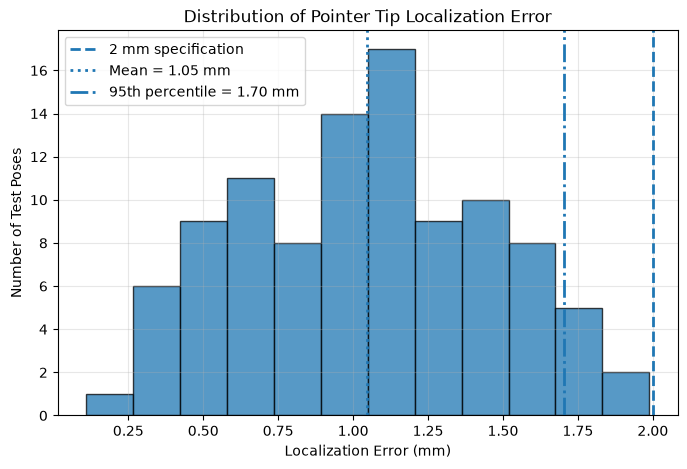

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=12,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    TIP_ERROR_SPEC_MM,
    linestyle="--",
    linewidth=2,
    label="2 mm specification"
)

plt.axvline(
    np.mean(errors),
    linestyle=":",
    linewidth=2,
    label=f"Mean = {np.mean(errors):.2f} mm"
)

plt.axvline(
    np.percentile(errors, 95),
    linestyle="-.",
    linewidth=2,
    label=f"95th percentile = {np.percentile(errors, 95):.2f} mm"
)

plt.xlabel("Localization Error (mm)")
plt.ylabel("Number of Test Poses")
plt.title("Distribution of Pointer Tip Localization Error")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [21]:
actual_tip = ptr.get_actual_tip_position()

actual_tip_array = np.array([
    actual_tip.x,
    actual_tip.y,
    actual_tip.z
])

local_tip_error = np.linalg.norm(
    p_tip_est.vec.ravel() - actual_tip_array
)

print(f"Local tip-calibration error: {local_tip_error:.3f} mm")

Local tip-calibration error: 1.330 mm


In [22]:
error = np.linalg.norm(
    tip_predicted.vec.ravel() - tip_true.vec.ravel()
)

print(f"Localization error: {error:.3f} mm")

Localization error: 1.625 mm


In [23]:
print(f"Mean error: {np.mean(errors):.3f} mm")
print(f"Max error: {np.max(errors):.3f} mm")
print(f"Poses meeting 2 mm: {np.sum(errors <= 2)} / {len(errors)}")
print(f"Rotation contribution: {np.mean(rotation_errors):.3f} mm")
print(f"Translation contribution: {np.mean(translation_errors):.3f} mm")
print(f"Local tip-calibration error: {local_tip_error:.3f} mm")
print(f"Localization error: {error:.3f} mm")
from scipy import stats

tip_errors = np.asarray(
    [result[1] for result in test_results],
    dtype=float
)

tip_n = len(tip_errors)
tip_mean = tip_errors.mean()
tip_se = stats.sem(tip_errors)
tip_spec = TIP_ERROR_SPEC_MM

tip_t_stat = (tip_mean - tip_spec) / tip_se
tip_p_value = stats.t.cdf(tip_t_stat, df=tip_n - 1)

tip_upper_95 = (
    tip_mean
    + stats.t.ppf(0.95, df=tip_n - 1) * tip_se
)

tip_reject = tip_p_value < 0.05

print(f"95% upper confidence bound: {tip_upper_95:.3f} mm")
print(f"Tip-error t-test p-value: {tip_p_value:.6g}")
print(
    "95% test decision: "
    + ("Reject H0" if tip_reject else "Fail to reject H0")
)

Mean error: 1.045 mm
Max error: 1.989 mm
Poses meeting 2 mm: 100 / 100
Rotation contribution: 0.351 mm
Translation contribution: 1.274 mm
Local tip-calibration error: 1.330 mm
Localization error: 1.625 mm
95% upper confidence bound: 1.113 mm
Tip-error t-test p-value: 3.45502e-42
95% test decision: Reject H0
